In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers, models, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import os
import cv2
from glob import glob
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# GPU Configuration for T4
import tensorflow as tf

# Check for GPU availability
print("GPU Available: ", tf.test.is_gpu_available())
print("GPU Device Name: ", tf.test.gpu_device_name())

# Set memory growth to avoid OOM errors
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU configured: {gpus}")
    except RuntimeError as e:
        print(e)

# Verify TensorFlow can see the GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found')
else:
    print('Found GPU at: {}'.format(device_name))

GPU Available:  True
GPU Device Name:  /device:GPU:0
GPU configured: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found GPU at: /device:GPU:0


In [4]:
# 1. Imports and basic setup
import os
import pathlib
import json
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from tensorflow.keras import layers

# Enable mixed precision for speed on GPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow version:", tf.__version__)
print("Mixed precision policy:", mixed_precision.global_policy())
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
Mixed precision policy: <DTypePolicy "mixed_float16">
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# 3. Root directory on Drive
ROOT_DIR = "/content/drive/MyDrive/Cross-Dataset Generalization Thesis"
EUROSAT_DIR = os.path.join(ROOT_DIR, "eurosat")
MODELS_DIR = os.path.join(EUROSAT_DIR, "models")
LOGS_DIR = os.path.join(EUROSAT_DIR, "logs")
FIGS_DIR = os.path.join(EUROSAT_DIR, "figs")
METRICS_DIR = os.path.join(EUROSAT_DIR, "metrics")

for d in [ROOT_DIR, EUROSAT_DIR, MODELS_DIR, LOGS_DIR, FIGS_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)
    print("Ensured directory:", d)


Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/logs
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/figs
Ensured directory: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics


In [8]:
# 4. Load EuroSAT (RGB) via TFDS
DATASET_NAME = "eurosat/rgb"

# TFDS defines only a 'train' split; do custom train/val/test split
(ds_full,), ds_info = tfds.load(
    DATASET_NAME,
    split=["train"],
    with_info=True,
    as_supervised=True
)

num_classes = ds_info.features["label"].num_classes
class_names = ds_info.features["label"].names
print("Classes:", num_classes, class_names)

num_examples = ds_info.splits["train"].num_examples
train_size = int(0.6 * num_examples)
val_size = int(0.2 * num_examples)
test_size = num_examples - train_size - val_size

print("Total:", num_examples)
print("Train/Val/Test:", train_size, val_size, test_size)

ds_train = ds_full.take(train_size)
ds_temp = ds_full.skip(train_size)
ds_val = ds_temp.take(val_size)
ds_test = ds_temp.skip(val_size)

Classes: 10 ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total: 27000
Train/Val/Test: 16200 5400 5400


Sample images from EuroSAT dataset:


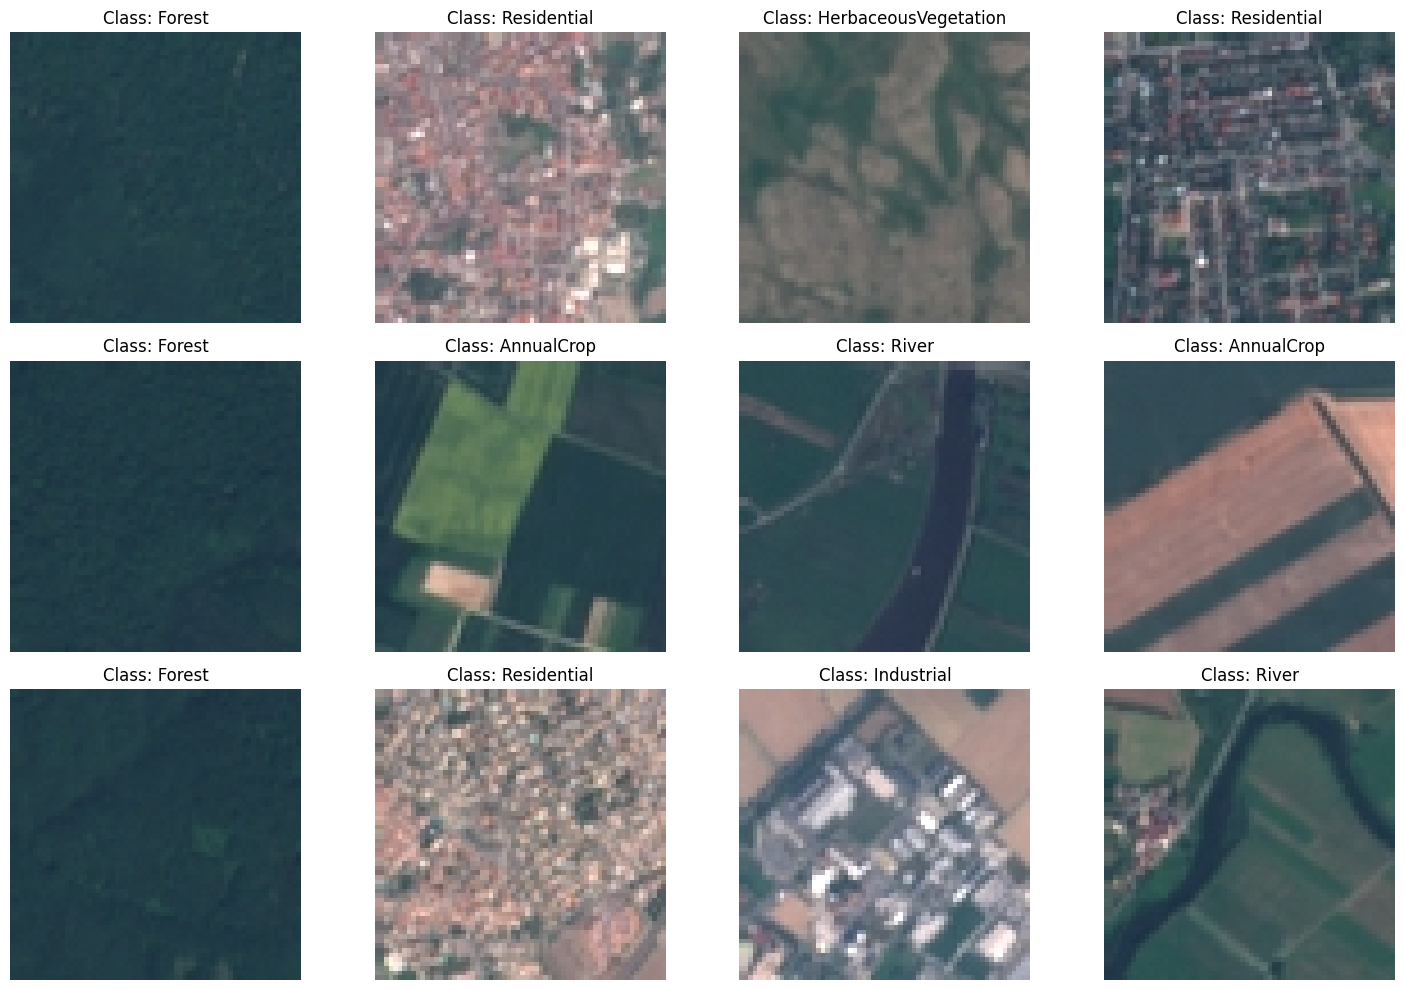

In [30]:
# Visualize sample images from the dataset
def visualize_samples(dataset, class_names, num_samples=12):
    # Take a batch from the dataset and convert to numpy arrays for visualization
    # Batch the dataset before taking a sample to ensure labels is an array
    batched_dataset = dataset.batch(num_samples)
    # The dataset might contain tf.uint8 images after initial load, so ensure float32 for plt.imshow
    images, labels = next(batched_dataset.map(lambda img, lbl: (tf.image.convert_image_dtype(img, tf.float32), lbl)).take(1).as_numpy_iterator())

    plt.figure(figsize=(15, 10))
    for i in range(min(num_samples, len(images))):
        plt.subplot(3, 4, i+1)
        plt.imshow(images[i])
        # Assumes labels are integer labels
        class_idx = labels[i]
        plt.title(f'Class: {class_names[class_idx]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display sample images from the original full dataset (before any custom preprocessing or splitting)
print("Sample images from EuroSAT dataset:")
visualize_samples(ds_full, class_names)

In [9]:
# 6. Preprocessing and augmentation
IMG_SIZE = 128  # small but enough; faster than 224
BATCH_SIZE = 64
AUTO = tf.data.AUTOTUNE

def preprocess(image, label, training=False):
    # Convert to float and resize
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    if training:
        # Light, fast augmentations
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
    # ResNet50 expects [0, 255] then specific preprocessing, so rescale later
    return image, label

def prepare_ds(ds, training=False):
    if training:
        ds = ds.shuffle(1000, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: preprocess(x, y, training=training), num_parallel_calls=AUTO)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTO)
    return ds

train_ds = prepare_ds(ds_train, training=True)
val_ds = prepare_ds(ds_val, training=False)
test_ds = prepare_ds(ds_test, training=False)

In [10]:
# 7. Apply ResNet50 preprocessing via Keras
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess

def add_resnet_preprocess(ds):
    def _f(images, labels):
        images = resnet50_preprocess(images * 255.0)  # expects 0-255
        return images, labels
    return ds.map(_f, num_parallel_calls=AUTO)

train_ds = add_resnet_preprocess(train_ds)
val_ds = add_resnet_preprocess(val_ds)
test_ds = add_resnet_preprocess(test_ds)

In [11]:
# 8. Save class mapping for EuroSAT
class_mapping_path = os.path.join(METRICS_DIR, "eurosat_class_mapping.json")
with open(class_mapping_path, "w") as f:
    json.dump({"class_names": class_names}, f, indent=2)
print("Saved class mapping to:", class_mapping_path)

Saved class mapping to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics/eurosat_class_mapping.json


In [13]:
# 9. Build ResNet50 model
base_model = keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

# Optionally freeze base for first few epochs to stabilize training
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)  # force float32 for numerics

model = keras.Model(inputs, outputs, name="resnet50_eurosat")

model.summary()

Model: "resnet50_eurosat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
# 10. Compile model
initial_lr = 1e-3
optimizer = keras.optimizers.Adam(learning_rate=initial_lr)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# 11. Callbacks
csv_log_path = os.path.join(LOGS_DIR, "eurosat_resnet50_history.csv")
checkpoint_path = os.path.join(MODELS_DIR, "eurosat_resnet50_best.weights.h5")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.CSVLogger(csv_log_path),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    )
]

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Training complete. History logged to:", csv_log_path)

Epoch 1/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8273 - loss: 0.5473
Epoch 1: val_accuracy improved from -inf to 0.93796, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_resnet50_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 55s 154ms/step - accuracy: 0.8276 - loss: 0.5465 - val_accuracy: 0.9380 - val_loss: 0.1933 - learning_rate: 0.0010
Epoch 2/20
252/254 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9352 - loss: 0.1872
Epoch 2: val_accuracy improved from 0.93796 to 0.94926, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_resnet50_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 25s 97ms/step - accuracy: 0.9352 - loss: 0.1871 - val_accuracy: 0.9493 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 3/20
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9476 - loss: 0.1559
Epoch 3: val_accuracy improved from 0.94926 to 0.95352, saving model to /content/drive/MyDrive/Cr

In [16]:
# 12. Optional fine-tuning step (few extra epochs with base_model trainable)
base_model.trainable = True

# Recompile with lower LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=initial_lr * 0.1),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 5

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[
        keras.callbacks.CSVLogger(os.path.join(LOGS_DIR, "eurosat_resnet50_history_ft.csv"), append=True),
        keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            verbose=1
        )
    ]
)

Epoch 1/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9225 - loss: 0.2907
Epoch 1: val_accuracy improved from -inf to 0.95148, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_resnet50_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 166s 333ms/step - accuracy: 0.9226 - loss: 0.2902 - val_accuracy: 0.9515 - val_loss: 0.1638 - learning_rate: 1.0000e-04
Epoch 2/5
254/254 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9758 - loss: 0.0848
Epoch 2: val_accuracy improved from 0.95148 to 0.95296, saving model to /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_resnet50_best.weights.h5
254/254 ━━━━━━━━━━━━━━━━━━━━ 42s 163ms/step - accuracy: 0.9758 - loss: 0.0848 - val_accuracy: 0.9530 - val_loss: 0.1517 - learning_rate: 1.0000e-04
Epoch 3/5
253/254 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9725 - loss: 0.0860
Epoch 3: val_accuracy improved from 0.95296 to 0.97778, saving model to /content/drive/

In [17]:
# 13. Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 14. Collect predictions for confusion matrix and ROC
y_true = []
y_pred = []
y_score = [] # New list to store all predicted probabilities

for images, labels in test_ds:
    batch_preds = model.predict(images, verbose=0) # Get predictions for current batch
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(batch_preds, axis=-1).tolist())
    y_score.extend(batch_preds.tolist()) # Store raw probabilities

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score) # Convert list of lists to a 2D numpy array

85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.9860 - loss: 0.0467
Test loss: 0.051264259964227676
Test accuracy: 0.9850000143051147


In [18]:
print("\n--- Detailed Results ---")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


--- Detailed Results ---
Test Loss: 0.051264259964227676
Test Accuracy: 0.9850000143051147

Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       573
              Forest       0.99      1.00      1.00       575
HerbaceousVegetation       0.98      0.99      0.98       621
             Highway       0.97      0.97      0.97       504
          Industrial       0.99      0.99      0.99       501
             Pasture       0.99      0.97      0.98       397
       PermanentCrop       0.97      0.97      0.97       504
         Residential       1.00      0.99      1.00       608
               River       0.97      0.99      0.98       511
             SeaLake       1.00      1.00      1.00       606

            accuracy                           0.98      5400
           macro avg       0.98      0.98      0.98      5400
        weighted avg       0.99      0.98      0.98      5400



In [19]:
# 15. Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm.shape)

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Save metrics for Day 2-5
metrics_path = os.path.join(METRICS_DIR, "eurosat_resnet50_test_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(
        {
            "test_loss": float(test_loss),
            "test_accuracy": float(test_acc),
            "classification_report": report
        },
        f,
        indent=2
    )
print("Saved metrics to:", metrics_path)

# Save confusion matrix as .npy
cm_path = os.path.join(METRICS_DIR, "eurosat_resnet50_confusion_matrix.npy")
np.save(cm_path, cm)
print("Saved confusion matrix to:", cm_path)

Confusion matrix shape: (10, 10)
Saved metrics to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics/eurosat_resnet50_test_metrics.json
Saved confusion matrix to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/metrics/eurosat_resnet50_confusion_matrix.npy


In [20]:
# 17. Save full model for reuse in Day 2-5
full_model_path = os.path.join(MODELS_DIR, "eurosat_resnet50_full.keras") # Added .keras extension
model.save(full_model_path)
print("Saved full model to:", full_model_path)

Saved full model to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/models/eurosat_resnet50_full.keras


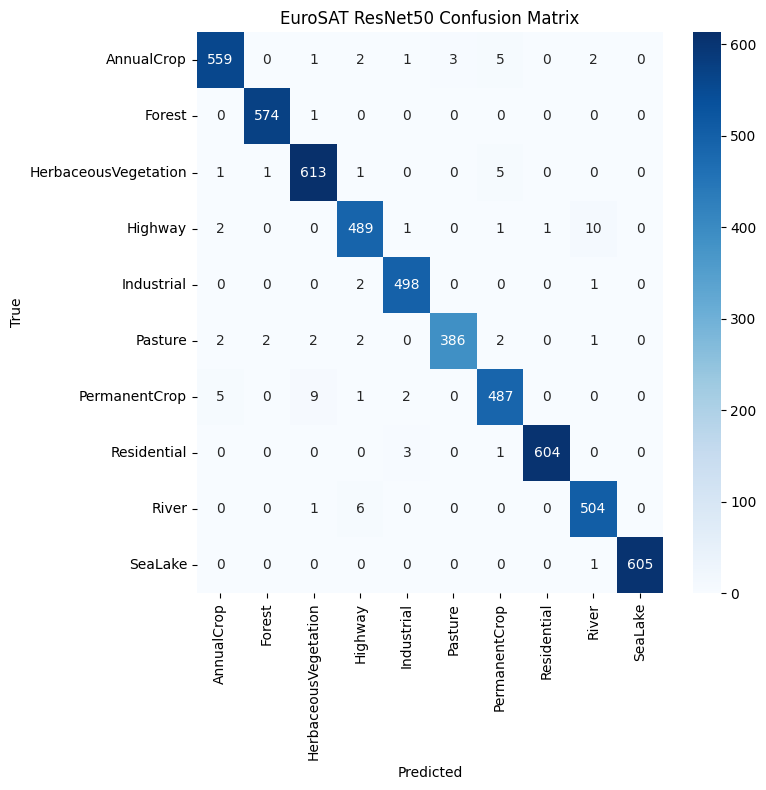

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 10})
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EuroSAT ResNet50 Confusion Matrix")
plt.tight_layout()
plt.show() # Display the plot directly

In [22]:
# 16. Plot confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure FIGS_DIR is defined, which it is from earlier cells.

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 10})
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EuroSAT ResNet50 Confusion Matrix")

fig_path = os.path.join(FIGS_DIR, "eurosat_resnet50_confusion_matrix.png")
plt.tight_layout()
plt.savefig(fig_path, dpi=300)
plt.close()
print("Saved confusion matrix figure to:", fig_path)

Saved confusion matrix figure to: /content/drive/MyDrive/Cross-Dataset Generalization Thesis/eurosat/figs/eurosat_resnet50_confusion_matrix.png


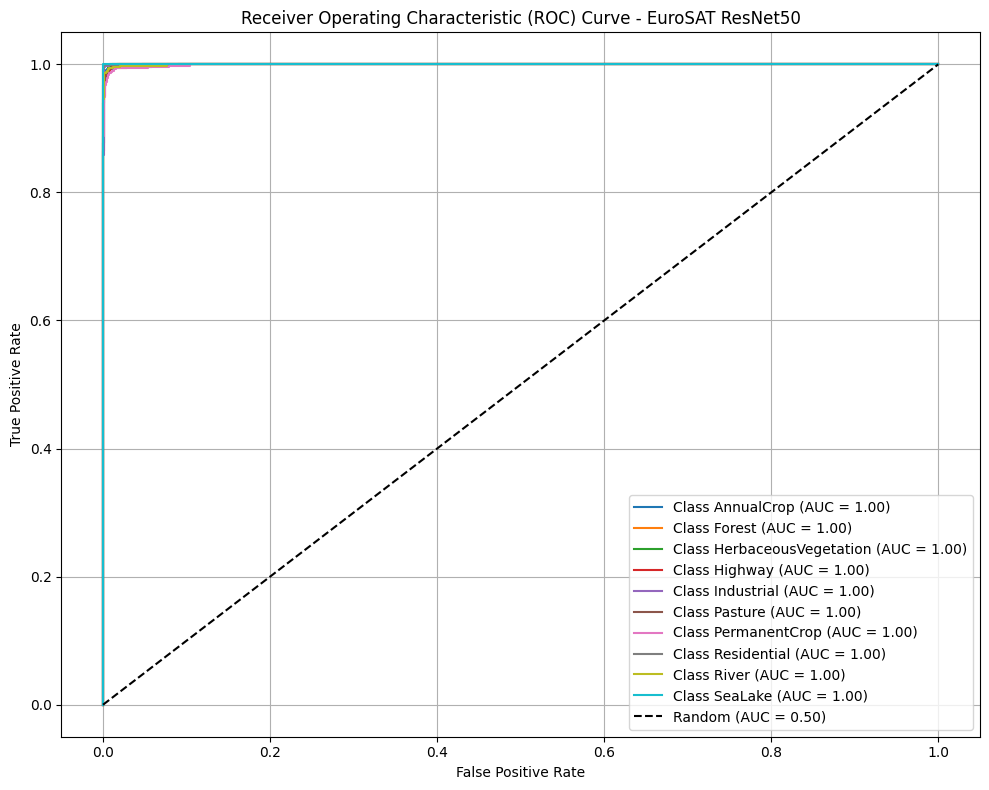

In [23]:
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Convert y_true to one-hot encoding for ROC curve calculation
y_true_one_hot = to_categorical(y_true, num_classes=num_classes)

plt.figure(figsize=(10, 8))

# Calculate ROC curve and AUC for each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], y_score[:, i]) # Use y_score instead of preds
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - EuroSAT ResNet50')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

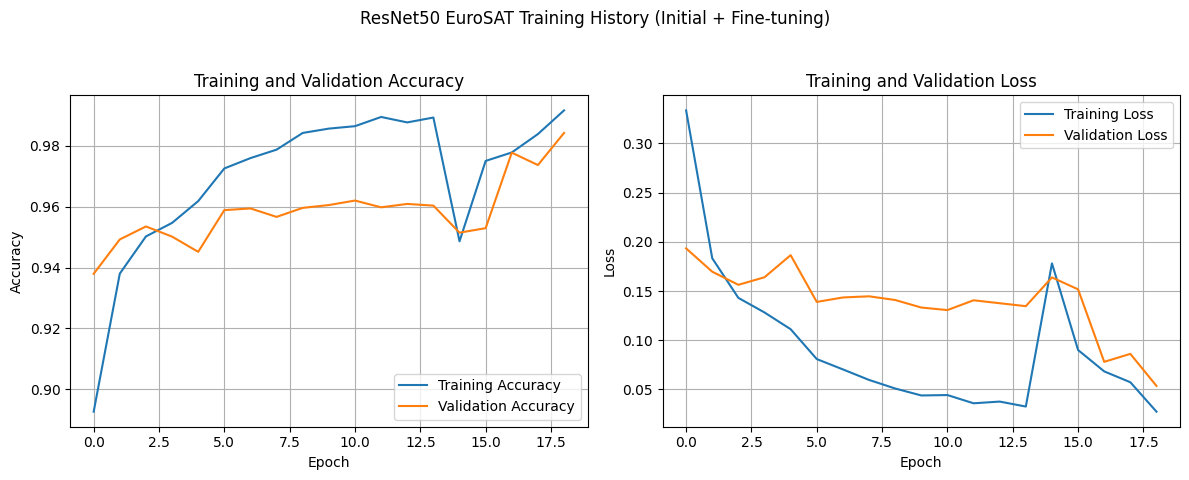

In [24]:
import matplotlib.pyplot as plt

def plot_history(history, history_ft=None, title='Model Training History'):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    if not acc:
        print("Warning: Training accuracy data not found in history. Cannot plot.")
        return

    epochs_range = range(len(acc))

    if history_ft:
        ft_acc = history_ft.history.get('accuracy', [])
        ft_val_acc = history_ft.history.get('val_accuracy', [])
        ft_loss = history_ft.history.get('loss', [])
        ft_val_loss = history_ft.history.get('val_loss', [])

        acc = acc + ft_acc
        val_acc = val_acc + ft_val_acc
        loss = loss + ft_loss
        val_loss = val_loss + ft_val_loss
        epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    if val_acc:
        plt.plot(epochs_range[:len(val_acc)], val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    if val_loss:
        plt.plot(epochs_range[:len(val_loss)], val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Call the function to plot the history
plot_history(history, history_ft, title='ResNet50 EuroSAT Training History (Initial + Fine-tuning)')

In [25]:
print("\n--- Overall Model Metrics ---")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision (Macro Avg): {report['macro avg']['precision']:.4f}")
print(f"Recall (Macro Avg): {report['macro avg']['recall']:.4f}")
print(f"F1-score (Macro Avg): {report['macro avg']['f1-score']:.4f}")


--- Overall Model Metrics ---
Accuracy: 0.9850
Precision (Macro Avg): 0.9847
Recall (Macro Avg): 0.9842
F1-score (Macro Avg): 0.9844
